<a href="https://colab.research.google.com/github/Cami87029i/Inteligencia-Artificial-1/blob/main/Laboratorio5_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import torch
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm
import numpy as np
import pandas as pd
from matplotlib import pyplot
from sklearn.datasets import fetch_openml

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {device}")

Dispositivo: cpu


In [2]:
class ModeloPersonalizado(torch.nn.Module):
    def __init__(self, D_in, H, D_out):
        super(ModeloPersonalizado, self).__init__()
        self.fc1  = torch.nn.Linear(D_in, H)
        self.relu = torch.nn.ReLU()
        self.fc2  = torch.nn.Linear(H, D_out)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

class ModelCustom2(torch.nn.Module):
    def __init__(self, D_in, H, D_out):
        super(ModelCustom2, self).__init__()
        self.fc1  = torch.nn.Linear(D_in, H)
        self.relu = torch.nn.ReLU()
        self.fc2  = torch.nn.Linear(H, D_out)

    def forward(self, x):
        x1 = self.fc1(x)
        x  = self.relu(x1)
        x  = self.fc2(x + x1)
        return x


In [14]:
def fit(model, dataloader, epochs=5, PATH="./checkpoint.pt"):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.CrossEntropyLoss()
    best_acc  = 0
    historial_loss = []   # ← guarda el loss de cada época

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss, train_acc = [], []
        bar = tqdm(dataloader['train'])

        for batch in bar:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss  = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
            acc = (y == torch.argmax(y_hat, axis=1)).sum().item() / len(y)
            train_acc.append(acc)
            bar.set_description(f"loss {np.mean(train_loss):.5f} acc {np.mean(train_acc):.5f}")

        val_loss, val_acc = [], []
        model.eval()
        with torch.no_grad():
            bar = tqdm(dataloader['test'])
            for batch in bar:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss  = criterion(y_hat, y)
                val_loss.append(loss.item())
                acc = (y == torch.argmax(y_hat, axis=1)).sum().item() / len(y)
                val_acc.append(acc)
                bar.set_description(f"val_loss {np.mean(val_loss):.5f} val_acc {np.mean(val_acc):.5f}")

        val_acc = np.mean(val_acc)
        historial_loss.append(np.mean(train_loss))  # ← guarda el loss de esta época

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), PATH)
            print(f"Best model saved at epoch {epoch} with val_acc {val_acc:.5f}")

        print(f"Epoch {epoch}/{epochs} loss {np.mean(train_loss):.5f} "
              f"val_loss {np.mean(val_loss):.5f} acc {np.mean(train_acc):.5f} val_acc {val_acc:.5f}")

    model.load_state_dict(torch.load(PATH))
    return historial_loss  # ← esta línea es la que faltaba


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data  = pd.read_csv('/content/drive/MyDrive/IA/slice_localization_data.csv')
X     = data.iloc[:, :-1].values.astype(np.float32)
y_raw = data.iloc[:, -1].values

# Binarización: 1 = mitad superior (> 50), 0 = mitad inferior
y = (y_raw > 50).astype(int)

print(f"X: {X.shape}  |  y: {y.shape}")
print(f"Clase 0: {(y==0).sum()}  |  Clase 1: {(y==1).sum()}")
# Clase 0 (mitad inferior): 31431 imágenes — Clase 1 (mitad superior): 22069 imágenes
# Las clases no están perfectamente balanceadas (59% vs 41%) pero es aceptable

X: (53500, 385)  |  y: (53500,)
Clase 0: 31431  |  Clase 1: 22069


Grafica 1: Distribución de clases y datos

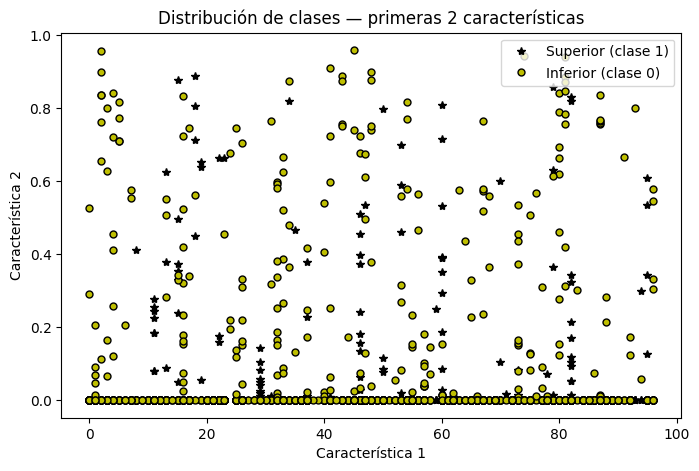

In [15]:
def plotData(X, y):
    """Grafica los puntos de datos coloreados por clase."""
    fig = pyplot.figure(figsize=(8, 5))
    pos = y == 1
    neg = y == 0
    pyplot.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=6, label='Superior (clase 1)')
    pyplot.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=5, mec='k', mew=1, label='Inferior (clase 0)')
    pyplot.xlabel('Característica 1')
    pyplot.ylabel('Característica 2')
    pyplot.legend()
    pyplot.title('Distribución de clases — primeras 2 características')
    pyplot.show()

# Visualizamos con las 2 primeras características (muestra de 2000 puntos para que no se sature)
muestra = np.random.choice(len(X), 2000, replace=False)
plotData(X[muestra], y[muestra])


In [9]:
# Normalización segura — elimina columnas con sigma = 0
mu, sigma = X.mean(axis=0), X.std(axis=0)
cols_validas = sigma > 0          # solo columnas con variación
X = X[:, cols_validas]            # elimina las columnas planas
mu, sigma = X.mean(axis=0), X.std(axis=0)  # recalcula sin ellas
X_norm = (X - mu) / sigma

print(f"Columnas originales: 385  |  Columnas válidas: {X.shape[1]}")

np.random.seed(42)
idx     = np.random.permutation(len(X_norm))
m_train = int(0.8 * len(X_norm))
X_train, X_test = X_norm[idx[:m_train]], X_norm[idx[m_train:]]
y_train, y_test = y[idx[:m_train]],      y[idx[m_train:]]

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


Columnas originales: 385  |  Columnas válidas: 380
Train: (42800, 380)  |  Test: (10700, 380)


Dataset y Dataloader

In [16]:
class SliceDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        return self.X[ix], self.y[ix]

dataloader = {
    'train': torch.utils.data.DataLoader(SliceDataset(X_train, y_train), batch_size=256, shuffle=True),
    'test':  torch.utils.data.DataLoader(SliceDataset(X_test,  y_test),  batch_size=256, shuffle=False)
}
print(f"D_in: {X_train.shape[1]}  |  Batches train: {len(dataloader['train'])}  |  Batches test: {len(dataloader['test'])}")


D_in: 380  |  Batches train: 168  |  Batches test: 42


Modelo y entrenamiento


In [17]:
modelo = ModeloPersonalizado(D_in=X_train.shape[1], H=128, D_out=2).to(device)
print(modelo)


ModeloPersonalizado(
  (fc1): Linear(in_features=380, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)


In [18]:
historial_loss = fit(modelo, dataloader, epochs=20, PATH="./slice_model.pt")

val_loss 0.02246 val_acc 0.99349: 100%|██████████| 42/42 [00:00<00:00, 155.94it/s]


Best model saved at epoch 1 with val_acc 0.99349
Epoch 1/20 loss 0.07220 val_loss 0.02246 acc 0.97414 val_acc 0.99349


val_loss 0.01459 val_acc 0.99514: 100%|██████████| 42/42 [00:00<00:00, 147.77it/s]


Best model saved at epoch 2 with val_acc 0.99514
Epoch 2/20 loss 0.01649 val_loss 0.01459 acc 0.99488 val_acc 0.99514


val_loss 0.01066 val_acc 0.99609: 100%|██████████| 42/42 [00:00<00:00, 163.42it/s]


...

Epoch 18/20 loss 0.00182 val_loss 0.00691 acc 0.99930 val_acc 0.99823


val_loss 0.00611 val_acc 0.99823: 100%|██████████| 42/42 [00:00<00:00, 168.85it/s]


Epoch 19/20 loss 0.00261 val_loss 0.00611 acc 0.99912 val_acc 0.99823


val_loss 0.00477 val_acc 0.99833: 100%|██████████| 42/42 [00:00<00:00, 158.04it/s]


Epoch 20/20 loss 0.00223 val_loss 0.00477 acc 0.99912 val_acc 0.99833


Grafica 2: Convergencia de costo

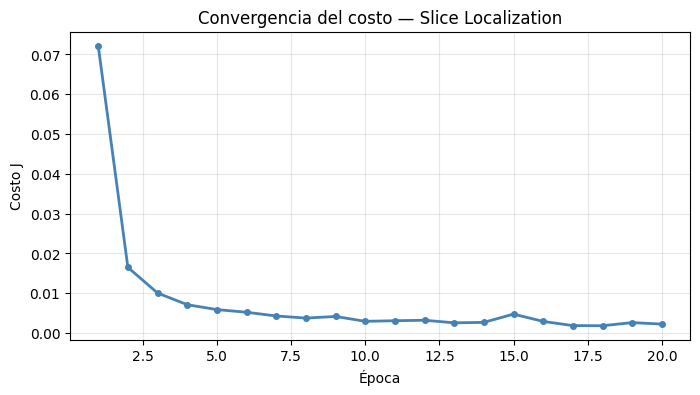

In [19]:
# Evolución del loss durante el entrenamiento — igual que el Lab 3
pyplot.figure(figsize=(8, 4))
pyplot.plot(np.arange(1, len(historial_loss) + 1), historial_loss, lw=2, color='steelblue', marker='o', ms=4)
pyplot.xlabel('Época')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del costo — Slice Localization')
pyplot.grid(True, alpha=0.3)
pyplot.show()

Evaluacion y predicción

In [20]:
acc = evaluate(modelo, dataloader)
print(f"Accuracy final: {acc*100:.2f}%")

acc 0.99870: 100%|██████████| 42/42 [00:00<00:00, 119.23it/s]

Accuracy final: 99.87%


Gráfica 3: Precisión por clase y límite de decisión

  Inferior (0): 99.87%
  Superior (1): 99.87%


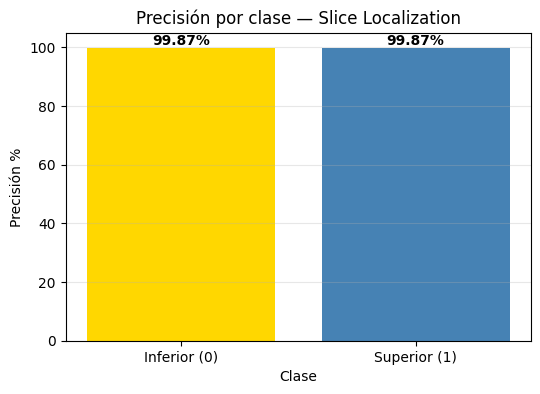

In [21]:
# Precisión por clase — igual que el Lab 3
all_preds, all_true = [], []
modelo.eval()
with torch.no_grad():
    for X_b, y_b in dataloader['test']:
        preds = torch.argmax(modelo(X_b.to(device)), dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y_b.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

precisiones = []
nombres     = ['Inferior (0)', 'Superior (1)']
for c in range(2):
    mask = (all_true == c)
    prec = np.mean(all_preds[mask] == all_true[mask]) * 100
    precisiones.append(prec)
    print(f"  {nombres[c]}: {prec:.2f}%")

pyplot.figure(figsize=(6, 4))
pyplot.bar(nombres, precisiones, color=['gold', 'steelblue'])
pyplot.xlabel('Clase')
pyplot.ylabel('Precisión %')
pyplot.title('Precisión por clase — Slice Localization')
pyplot.ylim(0, 105)
pyplot.grid(axis='y', alpha=0.3)
for i, v in enumerate(precisiones):
    pyplot.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')
pyplot.show()


In [23]:
modelo.eval()
X_pred = torch.tensor(X_test[:10], dtype=torch.float32).to(device)
with torch.no_grad():
    preds = torch.argmax(modelo(X_pred), dim=1).cpu().numpy()

print("10 predicciones vs valores reales:")
for i, (pred, real) in enumerate(zip(preds, y_test[:10])):
    zona_pred = "Superior" if pred == 1 else "Inferior"
    zona_real = "Superior" if real == 1 else "Inferior"
    ok = "good" if pred == real else "bad"
    print(f"  Ejemplo {i+1:2d}: {zona_pred}  |  Real: {zona_real}  {ok}")

10 predicciones vs valores reales:
  Ejemplo  1: Superior  |  Real: Superior  good
  Ejemplo  2: Inferior  |  Real: Inferior  good
  Ejemplo  3: Inferior  |  Real: Inferior  good
  Ejemplo  4: Superior  |  Real: Superior  good
  Ejemplo  5: Inferior  |  Real: Inferior  good
  Ejemplo  6: Inferior  |  Real: Inferior  good
  Ejemplo  7: Superior  |  Real: Superior  good
  Ejemplo  8: Inferior  |  Real: Inferior  good
  Ejemplo  9: Inferior  |  Real: Inferior  good
  Ejemplo 10: Superior  |  Real: Superior  good


In [24]:
guardar(modelo, "./slice.pt")


Guardado en ./slice.pt
